In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.load_config import load_config
from utils.load_data import load_pkl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.utils import resample

## Data loading

In [2]:
cfg = load_config()
marisma_pkl = cfg["data"]["MARISMA_PICKLE"]

In [3]:
marisma = load_pkl(marisma_pkl)

In [4]:
data, label, meta = marisma["data"], marisma["label"], marisma["meta"]

In [5]:
meta = pd.DataFrame.from_records(list(meta))

## Preprocessing

Normalize each spectrum

In [6]:
# axis=1 to work row by row
# keepdims=True keeps the dimensions needed for per-row normalization to work correctly
data_norm = (data - data.min(axis=1, keepdims=True)) / (
    data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)

Reduce dimensionality (there are 6000 features)

In [48]:
my_pca = PCA().fit(data_norm)

In [49]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

In [50]:
print(cumulative_explained_var)
print(cumulative_explained_var_ratio)

[22.05654523 37.97864638 46.11430022 ... 98.57128616 98.57128616
 98.57128617]
[0.22376238 0.38529117 0.46782691 ... 1.         1.         1.        ]


Text(0, 0.5, 'Cumulative explained variance')

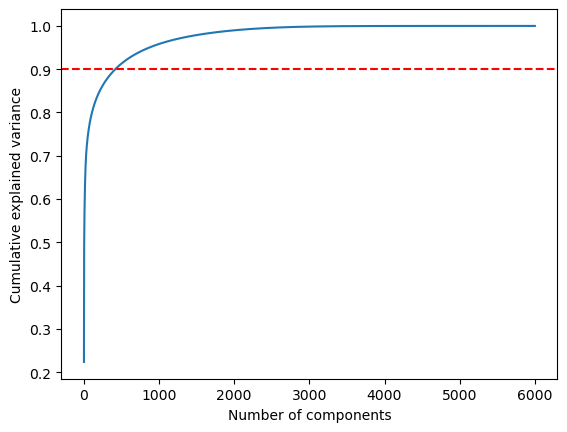

In [51]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

In [52]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.9) + 1
print(f"Number of components explaining 90% variance: {n_components}")

Number of components explaining 90% variance: 418


This indicates that 418 components are needed to account for 90% of the variance in our dataset. However, this is still a lot for t-SNE, so it is recommended to try and reduce the number of components

In [55]:
possible_dims = [30, 50, 100]
for dim in possible_dims:
    pca = PCA(n_components=dim).fit(data_norm)
    print(f"Explained variance with {dim} components: {np.sum(pca.explained_variance_ratio_)}")

Explained variance with 30 components: 0.7019925622343979
Explained variance with 50 components: 0.7423888490086569
Explained variance with 100 components: 0.7941803822587071


In [7]:
data_norm_pca = PCA(n_components=50).fit_transform(data_norm)

## t-SNE Embedding

In [ ]:
perplexity_values = [5, 10, 30, 50, 100, 200]
results = []

for perplexity in perplexity_values:
    # Fit the t-SNE
    my_tsne = TSNE(n_components=2, perplexity=perplexity)
    data_tsne = my_tsne.fit_transform(data_norm_pca)

    # Compute trustworthiness
    # mide si los puntos que eran vecinos en el espacio original siguen siéndolo en el embedding
    tw = trustworthiness(data_norm_pca, data_tsne, n_neighbors=perplexity)
    results.append((perplexity, tw))
    print(f"Perplexity={perplexity}, Trustworthiness={tw}")

In [16]:
my_tsne = TSNE(n_components=2, perplexity=50)
data_tsne = my_tsne.fit_transform(data_norm_pca)

In [17]:
n_samples = 10000
X_pca_sub, X_tsne_sub, y_sub = resample(
    data_norm_pca, data_tsne, label, n_samples=n_samples, stratify=label)

tw = trustworthiness(X_pca_sub, X_tsne_sub, n_neighbors=50)
print(f"Trustworthiness (10k stratified sample): {tw:.3f}")

Trustworthiness (10k stratified sample): 0.985


## Visualization

In [20]:
unique_labels = np.unique(label)
print(unique_labels)

['Enterobacter_cloacae_complex' 'Enterococcus_Faecium' 'Escherichia_Coli'
 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa' 'Staphylococcus_Aureus']
